In [9]:
import pandas as pd
import numpy as np

In [10]:
data = pd.read_csv("C:\IMDB\Advertising.csv") 

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\DELL\AppData\Local\Temp\ipykernel_12632\1171872458.py:1: SyntaxWarning: invalid escape sequence '\I'
  data = pd.read_csv("C:\IMDB\Advertising.csv")


In [11]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


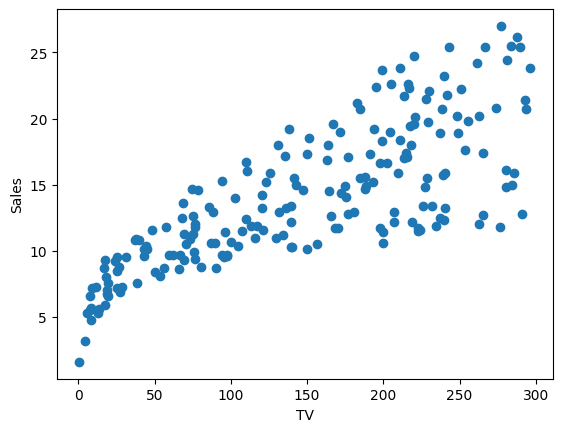

In [12]:
import matplotlib.pyplot as plt

plt.scatter(data['TV'] , data['sales']) 
plt.xlabel('TV') 
plt.ylabel('Sales')
plt.show()

In [13]:
import statsmodels.api as sm

x = sm.add_constant(data['TV'])
y = data['sales']
model = sm.OLS(y, x).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.47e-42
Time:                        14:47:50   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

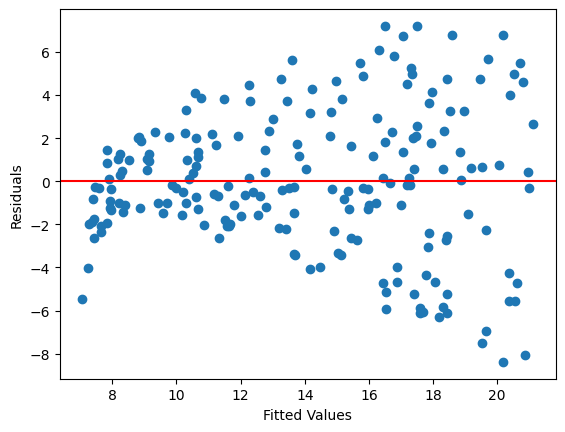

In [14]:
residuals = y - model.predict(x) 

plt.scatter(model.predict(x) , residuals) 
plt.xlabel('Fitted Values') 
plt.ylabel('Residuals')
plt.axhline(0, color='red') 
plt.show() 


In [15]:
results_df = pd.DataFrame({
    'Actual Sales': y,
    'Predicted Sales': model.predict(x),
    'Residual': y - model.predict(x)
})

print(results_df.head(10))

   Actual Sales  Predicted Sales  Residual
0          22.1        17.970775  4.129225
1          10.4         9.147974  1.252026
2           9.3         7.850224  1.449776
3          18.5        14.234395  4.265605
4          12.9        15.627218 -2.727218
5           7.2         7.446162 -0.246162
6          11.8         9.765950  2.034050
7          13.2        12.746498  0.453502
8           4.8         7.441409 -2.641409
9          10.6        16.530414 -5.930414


In [16]:
n = len(y)
sigma_squared = np.sum(residuals**2) / (n-2)

In [17]:
print(f"RSS directly from model: {model.ssr}")

RSS directly from model: 2102.5305831313512


In [18]:
import numpy as np

x = data['TV'] 
y = data['sales'] 

#calculate the mean of x and y 
x_bar = np.mean(x) 
y_bar = np.mean(y) 

# calculate the slope 
numerator = np.sum((x - x_bar) * (y - y_bar)) 
denominator = np.sum((x - x_bar)**2) 
beta_1 = numerator / denominator 

# calculate the intercept 
beta_0 = y_bar - beta_1 * x_bar

print(f"Intercept: {beta_0}")
print(f"Slope: {beta_1}") 

Intercept: 7.0325935491276965
Slope: 0.047536640433019736


In [19]:
se_beta_1 = np.sqrt(sigma_squared / np.sum((x - x_bar)**2)) 
se_beta_0 = np.sqrt(sigma_squared * (1 / n + (x_bar**2) / np.sum((x - x_bar)**2))) 
print(f"Standard Error of Intercept: {se_beta_0}") 
print(f"Standard Error of Slope: {se_beta_1}")

Standard Error of Intercept: 0.4578429402734785
Standard Error of Slope: 0.0026906071877968707


In [20]:
from scipy import stats 

t_val = stats.t.ppf(0.0975 , df=n-2) 
ci_beta_1 = (beta_1 - t_val * se_beta_1, beta_1 + t_val * se_beta_1)
ci_beta_0 = (beta_0 - t_val * se_beta_0, beta_0 + t_val * se_beta_0) 

print(f"95% Confidence Interval for Intercept: {ci_beta_0}")
print(f"95% Confidence Interval for Slope: {ci_beta_1}")


95% Confidence Interval for Intercept: (7.6279396844569325, 6.4372474137984605)
95% Confidence Interval for Slope: (0.051035313121927245, 0.04403796774411223)


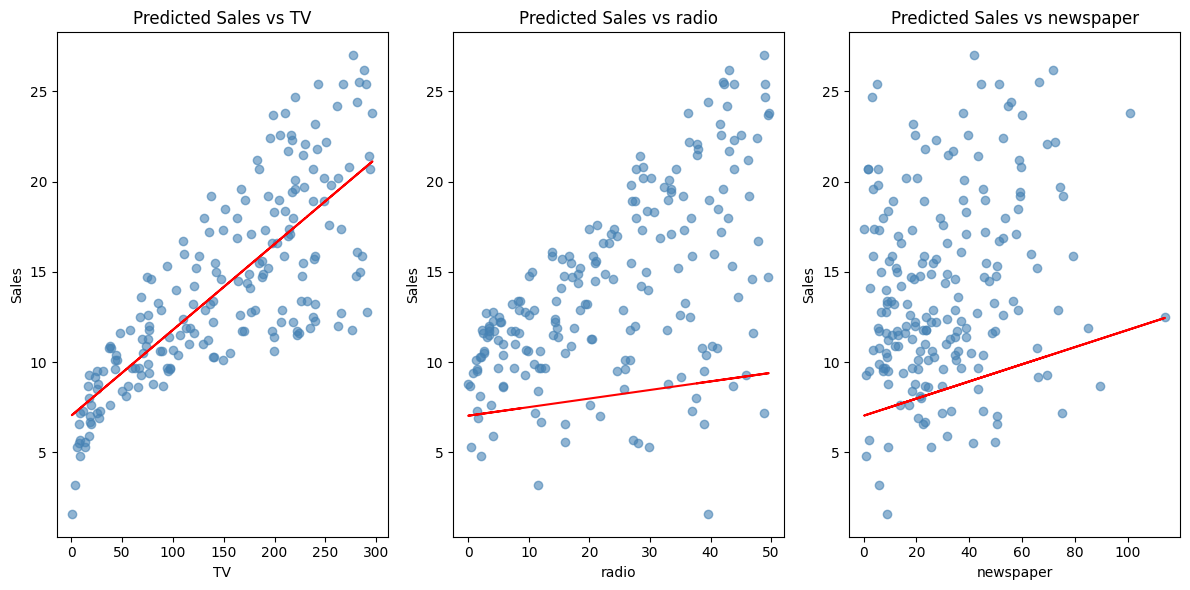

In [21]:
fig , axes = plt.subplots(1, 3, figsize=(12, 6)) 

features = ['TV' , 'radio' , 'newspaper']
for i , feature in enumerate(features): 
    axes[i].scatter(data[feature] , data['sales'] , alpha = 0.6 , color = 'steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sales')
    axes[i].plot(data[feature] , beta_0 + beta_1 * data[feature] , color = 'red') 
    axes[i].set_title(f"Predicted Sales vs {feature}") 

plt.tight_layout() 
plt.show() 

In [22]:
x = data['TV'].values
y = data['sales'].values

n =len(y) 
print(f'Number of observations: {n}')
print(f'x (TV) range: {x.min():.1f} to {x.max():.1f}')
print(f'y (Sales) range: {y.min():.1f} to {y.max():.1f}')

Number of observations: 200
x (TV) range: 0.7 to 296.4
y (Sales) range: 1.6 to 27.0


In [23]:
x = np.column_stack([np.ones(n) , x]) 
print('Design Matrix X shapes:' , x.shape)
print('First 5 rows of x :')
print(x[:5])
print('\n Columns 0 (ones for β₀) | Columns 1(Tv values for β₁)')

Design Matrix X shapes: (200, 2)
First 5 rows of x :
[[  1.  230.1]
 [  1.   44.5]
 [  1.   17.2]
 [  1.  151.5]
 [  1.  180.8]]

 Columns 0 (ones for β₀) | Columns 1(Tv values for β₁)


In [24]:
beta_example = np.array([7.0 , 0.05]) 
y_hat_example = x @ beta_example 
print('Example: Y_hat = X @ [7.0, 0.05]')
print(f'Predictions for first 5 samples: {y_hat_example[:5]}')
print(f'\nThis computed {n} predictions in ONE operation!')

Example: Y_hat = X @ [7.0, 0.05]
Predictions for first 5 samples: [18.505  9.225  7.86  14.575 16.04 ]

This computed 200 predictions in ONE operation!


In [25]:
XtX = x.T @ x                          # Step 1: Compute XᵀX
XtX_inv = np.linalg.inv(XtX)           # Step 2: Invert XᵀX
Xty = x.T @ y                          # Step 3: Compute Xᵀy
beta_normal = XtX_inv @ Xty            # Step 4: Multiply

beta0_ne = beta_normal[0]  # Intercept
beta1_ne = beta_normal[1]  # Slope

print('Normal Equation Results:')
print(f'  β₀ (Intercept): {beta0_ne:.6f}')
print(f'  β₁ (Slope):     {beta1_ne:.6f}')
print(f'\nInterpretation:')
print(f'  Base sales (TV=0): {beta0_ne:.2f} units')
print(f'  Each +1 unit of TV budget → +{beta1_ne:.4f} units of sales')

Normal Equation Results:
  β₀ (Intercept): 7.032594
  β₁ (Slope):     0.047537

Interpretation:
  Base sales (TV=0): 7.03 units
  Each +1 unit of TV budget → +0.0475 units of sales


In [26]:
y_hat_ne = x @ beta_normal
residuals = y - y_hat_ne 

rss_ne = np.sum(residuals ** 2 ) 

sigma_squared = rss_ne / (n - 2) 
se_beta_0 = np.sqrt(sigma_squared * XtX_inv[0][0]) 
se_beta_1 = np.sqrt(sigma_squared * XtX_inv[1][1]) 

t_val = stats.t.ppf(0.975 , df=n-2) 
ci_beta_1 = (beta1_ne - t_val * se_beta_1, beta1_ne + t_val * se_beta_1) 
ci_beta_0 = (beta0_ne - t_val * se_beta_0, beta0_ne + t_val * se_beta_0) 
print('Standard Errors:')
print(f'  SE(β₀): {se_beta_0:.6f}')
print(f'  SE(β₁): {se_beta_1:.6f}')
print(f'\n95% Confidence Intervals:')
print(f'  β₀: ({ci_beta_0[0]:.4f}, {ci_beta_0[1]:.4f})')
print(f'  β₁: ({ci_beta_1[0]:.4f}, {ci_beta_1[1]:.4f})')
print(f'\nRSS: {rss_ne:.4f}')

Standard Errors:
  SE(β₀): 0.457843
  SE(β₁): 0.002691

95% Confidence Intervals:
  β₀: (6.1297, 7.9355)
  β₁: (0.0422, 0.0528)

RSS: 2102.5306


In [27]:
x_sm = sm.add_constant(data['TV'])
model_sm = sm.OLS(data['sales'], x_sm).fit()
print('Statsmodels OLS Verification:')
print(model_sm.summary())

Statsmodels OLS Verification:
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.47e-42
Time:                        19:56:57   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326 

In [33]:
print(x.shape) 
print(y.shape)

(200, 2)
(200,)


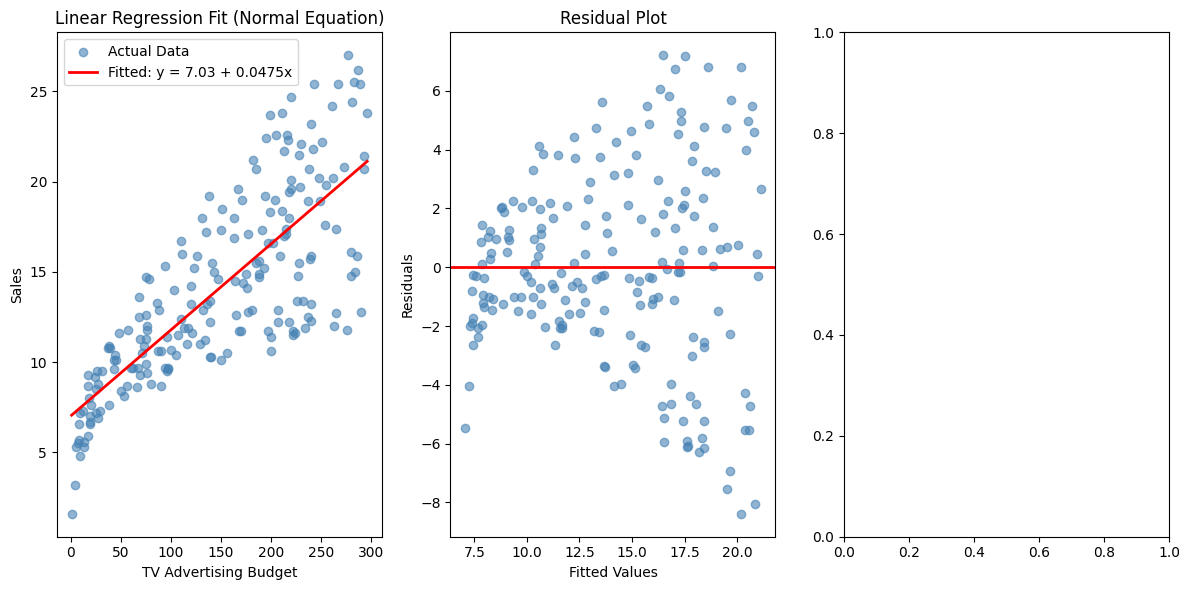

In [35]:
fig , (ax1 , ax2 , ax3) = plt.subplots(1, 3, figsize=(12, 6)) 

x_line = np.linspace(x[:, 1].min() , x[:, 1].max() , 100) 
y_line = beta0_ne + beta1_ne * x_line 

ax1.scatter(x[:, 1], y, alpha=0.6, color='steelblue', label='Actual Data')
ax1.plot(x_line, y_line, color='red', linewidth=2, label=f'Fitted: y = {beta0_ne:.2f} + {beta1_ne:.4f}x')
ax1.set_xlabel('TV Advertising Budget')
ax1.set_ylabel('Sales')
ax1.set_title('Linear Regression Fit (Normal Equation)')
ax1.legend()

# Plot 2: Residuals
ax2.scatter(y_hat_ne, residuals, alpha=0.6, color='steelblue')
ax2.axhline(0, color='red', linewidth=2)
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')

plt.tight_layout()
plt.savefig('02_normal_equation_results.png', dpi=100, bbox_inches='tight')
plt.show()

In [56]:
x = data['TV'].values  
y = data['sales'].values  

x = x.flatten()
y = y.flatten()


In [49]:
print(x.shape)
print(y.shape)

(200,)
(200,)


In [50]:
x = x.flatten()  
x_mean = np.mean(x)
x_std = np.std(x)

x_scaled = (x - x_mean) / x_std
print(x_scaled.shape) 

print('Feature Scaling (Standardization):')
print(f'  Original x → mean={x_mean:.2f}, std={x_std:.2f}')
print(f'  Scaled x   → mean={x_scaled.mean():.4f}, std={x_scaled.std():.4f}')

(200,)
Feature Scaling (Standardization):
  Original x → mean=147.04, std=85.64
  Scaled x   → mean=0.0000, std=1.0000


In [51]:
x_scaled = x_scaled.flatten()
print(x_scaled.shape)

(200,)


In [55]:
def gradient_descent(x , y , alpha=0.01 , n_iterations=1000):
    n = len(y) 
    beta0 = 0.0 
    beta1 = 0.0 
    cost_history = [] 

    x = x.flatten()  

    for i in range(n_iterations):
        y_hat = beta0 + beta1 * x

        cost = np.sum((y_hat - y)**2) / (2*n)
        cost_history.append(cost)

        error = y_hat - y
        grad_b0 = np.sum(error) / n
        grad_b1 = np.sum(error * x) / n

        beta0 = beta0 - alpha * grad_b0
        beta1 = beta1 - alpha * grad_b1

    return beta0, beta1, cost_history


alpha = 0.1 
n_iterations = 1000 

beta0_gd_scaled , beta1_gd_scaled , cost_history = gradient_descent(x_scaled , y , alpha , n_iterations)

print(f'Gradient Descent Results (on scaled x):')
print(f'  β₀ (scaled): {beta0_gd_scaled:.6f}')
print(f'  β₁ (scaled): {beta1_gd_scaled:.6f}')
print(f'  Final Cost:  {cost_history[-1]:.4f}') 

Gradient Descent Results (on scaled x):
  β₀ (scaled): 14.022500
  β₁ (scaled): 4.071006
  Final Cost:  5.2563


In [53]:
beta1_gd = beta1_gd_scaled / x_std
beta0_gd = beta0_gd_scaled - (beta1_gd_scaled * x_mean / x_std)

print(f'Gradient Descent Results (on original x):')
print(f'  β０ (original): {beta0_gd:.6f}')
print(f'  β１ (original): {beta1_gd:.6f}')
print(f'  Final Cost:    {cost_history[-1]:.4f}')

Gradient Descent Results (on original x):
  β０ (original): 7.032594
  β１ (original): 0.047537
  Final Cost:    5.2563


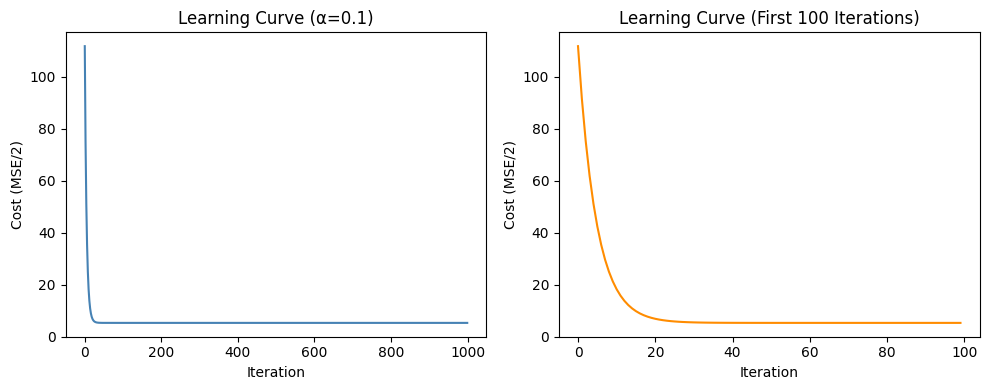

The cost decreases and converges — Gradient Descent is working!


In [54]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cost_history, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE/2)')
plt.title(f'Learning Curve (α={alpha})')

plt.subplot(1, 2, 2)
plt.plot(cost_history[:100], color='darkorange')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE/2)')
plt.title('Learning Curve (First 100 Iterations)')

plt.tight_layout()
plt.savefig('03_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('The cost decreases and converges — Gradient Descent is working!')

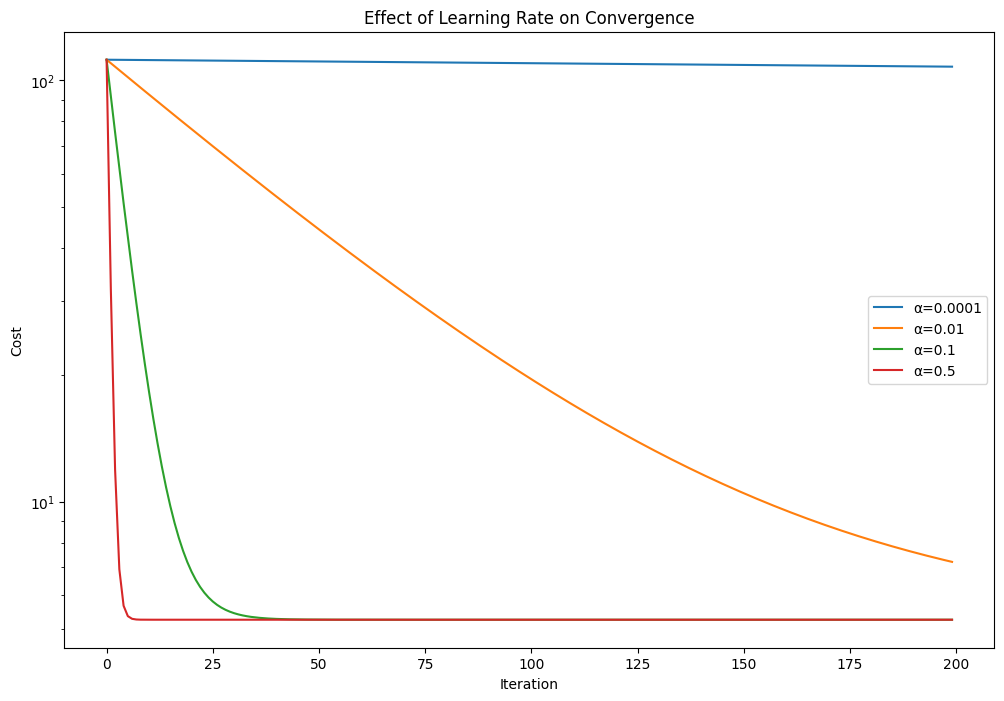

Insight: Too small α → slow convergence | Too large α → divergence | Just right → fast & stable


In [57]:
alphas = [0.0001 , 0.01 , 0.1 , 0.5] 

plt.figure(figsize = (12,8))

for alpha in alphas:
    _, _, cost_h = gradient_descent(x_scaled, y, alpha=alpha, n_iterations=200)
    plt.plot(cost_h, label=f'α={alpha}')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.yscale('log')  # Log scale to see differences clearly
plt.savefig('04_learning_rates.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: Too small α → slow convergence | Too large α → divergence | Just right → fast & stable')

In [59]:
x.flatten()
print(x.shape)

(200,)


In [61]:
X_pred = sm.add_constant(x)
y_hat_sm = model.predict(X_pred)


In [ ]:
y_hat_ne = beta0_ne + beta1_ne * x 
y_hat_ge = beta0_gd + beta1_gd * x 
y_hat_sm = model.predict(X_pred)

rss_ne = np.sum((y-y_hat_ne) **2)
rss_ge = np.sum((y - y_hat_ge) ** 2)
rss_sm = np.sum((y - y_hat_sm) ** 2)

print('Residual Sum of Squares (RSS):')
print(f'  Normal Equation: {rss_ne:.4f}')
print(f'  Gradient Descent: {rss_ge:.4f}')
print(f'  Statsmodels OLS:  {rss_sm:.4f}')

Residual Sum of Squares (RSS):
  Normal Equation: 2102.5306
  Gradient Descent: 2102.5306
  Statsmodels OLS:  2102.5306

Statsmodels OLS is the best fit!


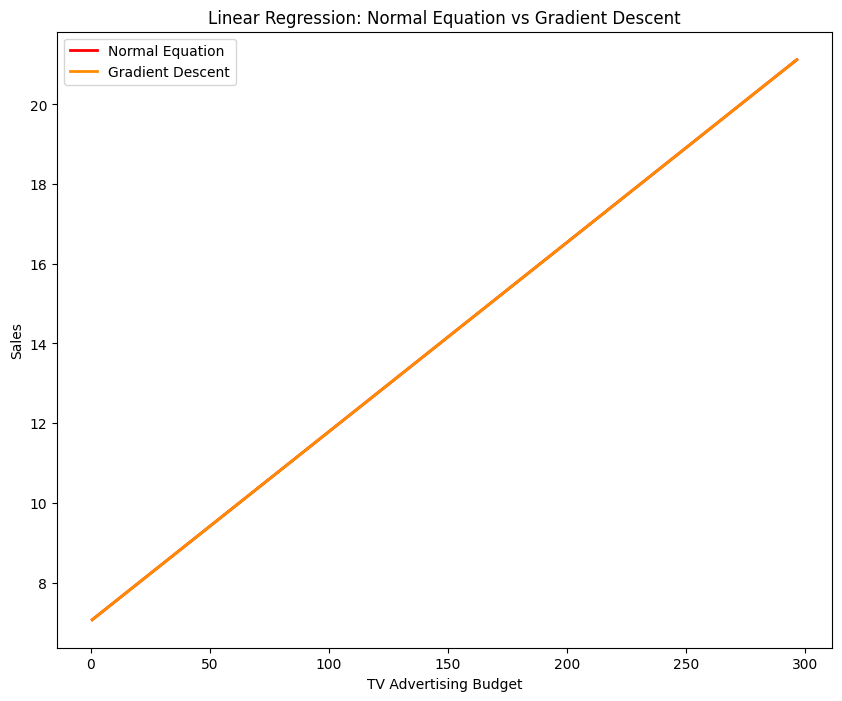

In [66]:
x_line = np.linspace(x.min() ,  x.max() , 100)
plt.figure(figsize=(10,8)) 

plt.plot(x_line , beta0_ne + beta1_ne * x_line , color='red' , linewidth=2 , label='Normal Equation') 
plt.plot(x_line , beta0_gd + beta1_gd * x_line , color='darkorange' , linewidth=2 , label='Gradient Descent') 

plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('Linear Regression: Normal Equation vs Gradient Descent')
plt.legend()
plt.savefig('05_final_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [67]:
results_df = pd.DataFrame({
    'Actual Sales'   : y,
    'Predicted (NE)' : y_hat_ne.round(4),
    'Predicted (GD)' : y_hat_ge.round(4),
    'Residual (NE)'  : (y - y_hat_ne).round(4)
})

print('First 10 rows:')
results_df.head(10)

First 10 rows:


,Actual Sales,Predicted (NE),Predicted (GD),Residual (NE)
0,22.1,17.9708,17.9708,4.1292
1,10.4,9.1480,9.1480,1.2520
2,9.3,7.8502,7.8502,1.4498
3,18.5,14.2344,14.2344,4.2656
4,12.9,15.6272,15.6272,-2.7272
5,7.2,7.4462,7.4462,-0.2462
6,11.8,9.7660,9.7660,2.0340
7,13.2,12.7465,12.7465,0.4535
8,4.8,7.4414,7.4414,-2.6414
9,10.6,16.5304,16.5304,-5.9304
